In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


X_train Shape: (19433, 39)
X_test Shape : (4859, 39)
y_train Shape: (19433,)
y_test Shape : (4859,)

Model Trained Successfully!

========== Evaluation Metrics ==========

Accuracy : 0.8928
Precision: 0.3213
Recall   : 0.8821
F1 Score : 0.4711
ROC-AUC  : 0.9508

========== Classification Report ==========

              precision    recall  f1-score   support

           0       0.99      0.89      0.94      4596
           1       0.32      0.88      0.47       263

    accuracy                           0.89      4859
   macro avg       0.66      0.89      0.71      4859
weighted avg       0.96      0.89      0.91      4859


Confusion Matrix

[[4106  490]
 [  31  232]]


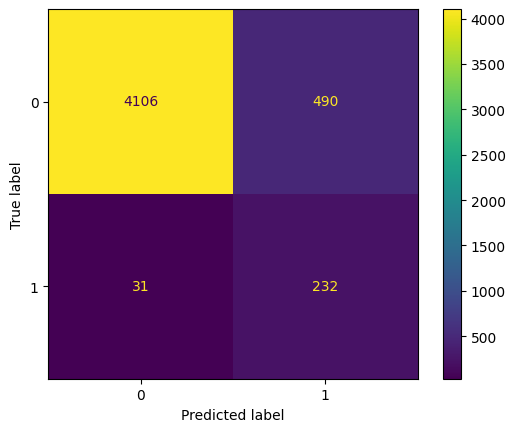

In [3]:
# =====================================================
# STEP 1: Import Libraries
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay




# =====================================================
# STEP 3: Load Dataset
# =====================================================

path = "/content/drive/MyDrive/"

X_train = pd.read_csv(path + "X_train.csv")
X_test = pd.read_csv(path + "X_test.csv")
y_train = pd.read_csv(path + "y_train.csv")
y_test = pd.read_csv(path + "y_test.csv")

# Convert target into 1-D array
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# =====================================================
# STEP 4: Display Dataset Information
# =====================================================

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

# =====================================================
# STEP 5: Create Gaussian Naive Bayes Model
# =====================================================

model = GaussianNB()

# =====================================================
# STEP 6: Train the Model
# =====================================================

model.fit(X_train, y_train)

print("\nModel Trained Successfully!")

# =====================================================
# STEP 7: Make Predictions
# =====================================================

y_pred = model.predict(X_test)

# Probability for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# STEP 8: Calculate Evaluation Metrics
# =====================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== Evaluation Metrics ==========\n")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(roc_auc,4))

# =====================================================
# STEP 9: Classification Report
# =====================================================

print("\n========== Classification Report ==========\n")
print(classification_report(y_test, y_pred))

# =====================================================
# STEP 10: Confusion Matrix
# =====================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix\n")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()